# Figure 9.4: Reconstruction of average latent vectors.

Pre-computed average vectors are reconstructed using saved decoder weights.

IntRangeSlider(value=(0, 255), description='Intensity', layout=Layout(width='600px'), max=255)

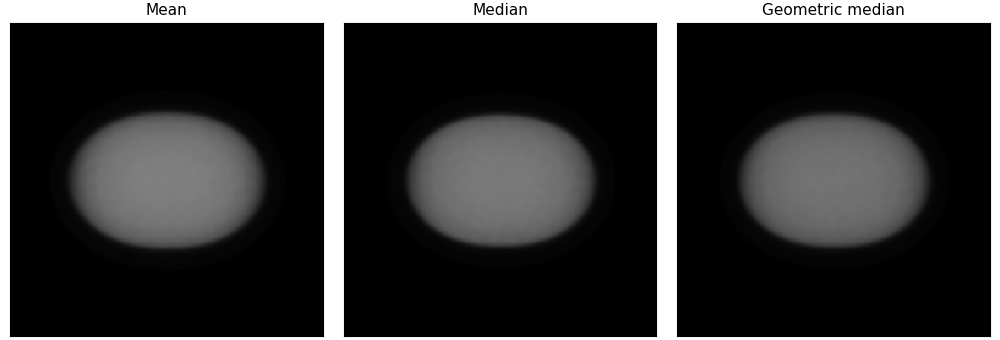

In [1]:
# ── Interactive backend & quiet TF logs ─────────────────────────────
try:
    get_ipython().run_line_magic("matplotlib", "widget")
except Exception:
    pass

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as W
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Reshape, Conv2D, Conv2DTranspose, ReLU
from tensorflow.keras.models import Model
from pathlib import Path

# ── GPU memory growth ─────────────────────────────────────────────────
try:
    gpus = tf.config.list_physical_devices("GPU")
    for g in gpus:
        tf.config.experimental.set_memory_growth(g, True)
except Exception:
    pass

# ── CONFIG ────────────────────────────────────────────────────────────
RESULTS_DIR     = Path("..") / "data" / "nucleus-ae"
CENTERS_NPZ     = RESULTS_DIR / "latent_centers.npz"
DECODER_WEIGHTS = RESULTS_DIR / "decoder_weights.h5"

# Model constants (must match training)
IMG_SHAPE   = (256, 256, 1)
LATENT_SIDE = 16  # after 4× AveragePooling2D from 256 → 16
BASE_CH     = 128

# Display constants
INTENSITY_MIN = 0
INTENSITY_MAX = 255

# ── Build decoder ─────────────────────────────────────────────────────
def build_decoder(latent_dim: int) -> Model:
    z_in = Input((latent_dim,), name="z_sampling")
    x = Dense(LATENT_SIDE * LATENT_SIDE * BASE_CH)(z_in)
    x = Reshape((LATENT_SIDE, LATENT_SIDE, BASE_CH))(x)
    
    for f in [BASE_CH, 64, 32, 16]:
        x = Conv2DTranspose(f, 3, strides=2, padding="same")(x)
        x = ReLU()(x)
        x = Conv2D(f, 3, padding="same")(x)
        x = ReLU()(x)
    
    out = Conv2D(1, 3, padding="same", activation="sigmoid", name="decoder_output")(x)
    return Model(z_in, out, name="decoder")

# ── Load latent centers and decoder ───────────────────────────────────
npz = np.load(CENTERS_NPZ)
z_mean     = npz["mean"].astype(np.float32)
z_median   = npz["median"].astype(np.float32)
z_geomed   = npz["geomedian"].astype(np.float32)
latent_dim = z_mean.shape[0]

decoder = build_decoder(latent_dim)
decoder.load_weights(DECODER_WEIGHTS)
decoder.trainable = False

# ── Decode all three centers ──────────────────────────────────────────
def decode_to_image(z_vec):
    """Decode latent vector to 0-255 grayscale image."""
    z_vec = np.asarray(z_vec, dtype=np.float32)[None, ...]
    img = decoder.predict(z_vec, verbose=0)[0, ..., 0]  # [0,1] range
    return (img * INTENSITY_MAX).astype(np.float32)     # [0,255] range

img_mean   = decode_to_image(z_mean)
img_median = decode_to_image(z_median)
img_geomed = decode_to_image(z_geomed)

imgs = [img_mean, img_median, img_geomed]
titles = ["Mean", "Median", "Geometric median"]

# ── Interactive figure with intensity slider ──────────────────────────
#| label: fig9d_data
fig, axes = plt.subplots(1, 3, figsize=(10, 3.4), constrained_layout=True)

ims = []
for ax, arr, title in zip(axes, imgs, titles):
    im = ax.imshow(arr, cmap="gray", vmin=INTENSITY_MIN, vmax=INTENSITY_MAX, 
                   interpolation="nearest")
    ax.set_title(title, fontsize=11)
    ax.set_xticks([])
    ax.set_yticks([])
    ims.append(im)

# Intensity range slider
rng = W.IntRangeSlider(
    value=[INTENSITY_MIN, INTENSITY_MAX],
    min=INTENSITY_MIN,
    max=INTENSITY_MAX,
    step=1,
    description="Intensity",
    continuous_update=True,
    readout=True,
    layout=W.Layout(width="600px")
)

def on_range_change(change):
    vmin, vmax = change["new"]
    if vmax <= vmin:
        return
    for im in ims:
        im.set_clim(vmin=vmin, vmax=vmax)
    fig.canvas.draw_idle()

rng.observe(on_range_change, names="value")

display(rng)
plt.show()